quantas imagens existem?

In [8]:
import os

caminho_da_pasta = r'C:\Users\ferre\Projects\LearnPython\BootcampAvanti\Fruit_dataset\test1' # Lembre-se de colocar o r antes da string no Windows
total_arquivos = 0

for raiz, diretorios, arquivos in os.walk(caminho_da_pasta):
    total_arquivos += len(arquivos)

print(f"Total de arquivos encontrados: {total_arquivos}")

Total de arquivos encontrados: 0


In [9]:
"""
Script de verificação de INTEGRIDADE DOS ARQUIVOS - ATIV-04-ET-01
Fruit_dataset - Bootcamp Avanti

Etapa 1: reconhecer os CSVs (rodar primeiro e conferir o print)
Etapa 2: comparar CSV x pasta de imagens + checar formatos
"""

import os
import pandas as pd
from PIL import Image

# ====== AJUSTE AQUI O CAMINHO BASE ======
base_path = r'C:\Users\ferre\Projects\LearnPython\BootcampAvanti\Bootcamp_Avanti_2026\Fruit_dataset'

conjuntos = {
    'train': {'csv': 'train.csv', 'pasta': 'train1'},
    'val':   {'csv': 'val.csv',   'pasta': 'val1'},
    'test':  {'csv': 'test.csv',  'pasta': 'test1'},
}

# =========================================================
# ETAPA 1 - RECONHECIMENTO (rode isso primeiro e olhe o print)
# =========================================================
print("############ ETAPA 1: RECONHECIMENTO DOS CSVs ############")
dfs = {}
for nome, info in conjuntos.items():
    caminho = os.path.join(base_path, info['csv'])
    df = pd.read_csv(caminho)
    dfs[nome] = df
    print(f"\n===== {info['csv']} =====")
    print("Colunas:", list(df.columns))
    print(df.head(3))

# =========================================================
# Coluna que contém o caminho do arquivo de imagem, ex: 'train/oil_palm/57.jpg'
# =========================================================
COLUNA_ARQUIVO = "image:FILE"

# O CSV guarda caminhos como 'train/oil_palm/57.jpg', mas a pasta local se
# chama 'train1' (não 'train'). Por isso vamos comparar apenas a parte
# RELATIVA depois do primeiro "/", ou seja: 'oil_palm/57.jpg'
def caminho_relativo_sem_split(caminho_csv):
    partes = caminho_csv.replace('\\', '/').split('/', 1)
    return partes[1] if len(partes) > 1 else partes[0]

print("\n\n############ ETAPA 2: INTEGRIDADE DOS ARQUIVOS ############")

for nome, info in conjuntos.items():
    print(f"\n===== Verificando conjunto: {nome} =====")

    df = dfs[nome]
    pasta_path = os.path.join(base_path, info['pasta'])

    if COLUNA_ARQUIVO not in df.columns:
        print(f"[ERRO] Coluna '{COLUNA_ARQUIVO}' não existe em {info['csv']}. "
              f"Colunas disponíveis: {list(df.columns)}")
        continue

    # Caminhos do CSV, já sem o prefixo 'train/'/'val/'/'test/'
    # Ex: 'train/oil_palm/57.jpg' -> 'oil_palm/57.jpg'
    arquivos_no_csv = set(
        caminho_relativo_sem_split(c) for c in df[COLUNA_ARQUIVO].astype(str)
    )
    print(f"Total de linhas no CSV: {len(df)}")

    # Lista real de arquivos na pasta, como caminho relativo
    # (inclui a subpasta da classe, ex: 'oil_palm/57.jpg')
    arquivos_na_pasta = set()
    for raiz, dirs, arquivos in os.walk(pasta_path):
        for a in arquivos:
            caminho_completo = os.path.join(raiz, a)
            rel = os.path.relpath(caminho_completo, pasta_path).replace('\\', '/')
            arquivos_na_pasta.add(rel)

    print(f"Total de arquivos na pasta: {len(arquivos_na_pasta)}")

    # --- 1. Existem no CSV mas não existem na pasta? ---
    faltando_na_pasta = arquivos_no_csv - arquivos_na_pasta
    # --- 2. Existem na pasta mas não estão no CSV? ---
    faltando_no_csv = arquivos_na_pasta - arquivos_no_csv

    print(f"Arquivos listados no CSV mas AUSENTES na pasta: {len(faltando_na_pasta)}")
    if faltando_na_pasta:
        print("Exemplos:", list(faltando_na_pasta)[:10])

    print(f"Arquivos na pasta mas AUSENTES no CSV: {len(faltando_no_csv)}")
    if faltando_no_csv:
        print("Exemplos:", list(faltando_no_csv)[:10])

    # --- 3. Verificar formatos das imagens ---
    formatos = {}
    imagens_corrompidas = []
    for raiz, dirs, arquivos in os.walk(pasta_path):
        for a in arquivos:
            caminho_completo = os.path.join(raiz, a)
            try:
                with Image.open(caminho_completo) as img:
                    formato = img.format  # ex: 'JPEG', 'PNG'
                    formatos[formato] = formatos.get(formato, 0) + 1
            except Exception as e:
                imagens_corrompidas.append((a, str(e)))

    print(f"Formatos encontrados: {formatos}")
    if imagens_corrompidas:
        print(f"[ATENÇÃO] {len(imagens_corrompidas)} imagens corrompidas/ilegíveis:")
        for nome_arq, erro in imagens_corrompidas[:10]:
            print(f"  - {nome_arq}: {erro}")

print("\n\nFIM DA VERIFICAÇÃO.")

############ ETAPA 1: RECONHECIMENTO DOS CSVs ############

===== train.csv =====
Colunas: ['image:FILE', 'category']
               image:FILE  category
0   train/oil_palm/57.jpg         0
1  train/oil_palm/881.jpg         0
2  train/oil_palm/450.jpg         0

===== val.csv =====
Colunas: ['image:FILE', 'category']
             image:FILE  category
0  val/oil_palm/102.jpg         0
1  val/oil_palm/637.jpg         0
2  val/oil_palm/186.jpg         0

===== test.csv =====
Colunas: ['image:FILE', 'category']
        image:FILE  category
0  test/28/596.jpg        -1
1   test/28/34.jpg        -1
2  test/28/686.jpg        -1


############ ETAPA 2: INTEGRIDADE DOS ARQUIVOS ############

===== Verificando conjunto: train =====
Total de linhas no CSV: 40000
Total de arquivos na pasta: 40001
Arquivos listados no CSV mas AUSENTES na pasta: 0
Arquivos na pasta mas AUSENTES no CSV: 1
Exemplos: ['classname.txt']
Formatos encontrados: {'JPEG': 39999, 'PNG': 1}
[ATENÇÃO] 1 imagens corrompidas/ilegí


===== Distribuição de classes: train =====
Número de classes distintas: 100
category
0     400
1     400
2     400
3     400
4     400
     ... 
95    400
96    400
97    400
98    400
99    400
Name: count, Length: 100, dtype: int64


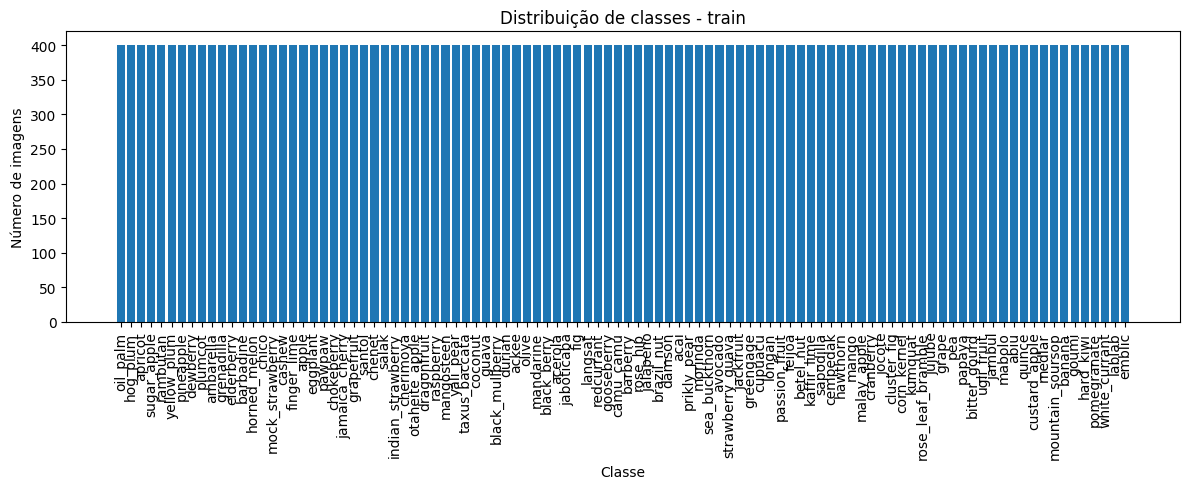

Classe com mais imagens: 400 | Classe com menos imagens: 400
Razão maior/menor: 1.00x
Classes relativamente balanceadas.

===== Distribuição de classes: val =====
Número de classes distintas: 100
category
0     50
1     50
2     50
3     50
4     50
      ..
95    50
96    50
97    50
98    50
99    50
Name: count, Length: 100, dtype: int64


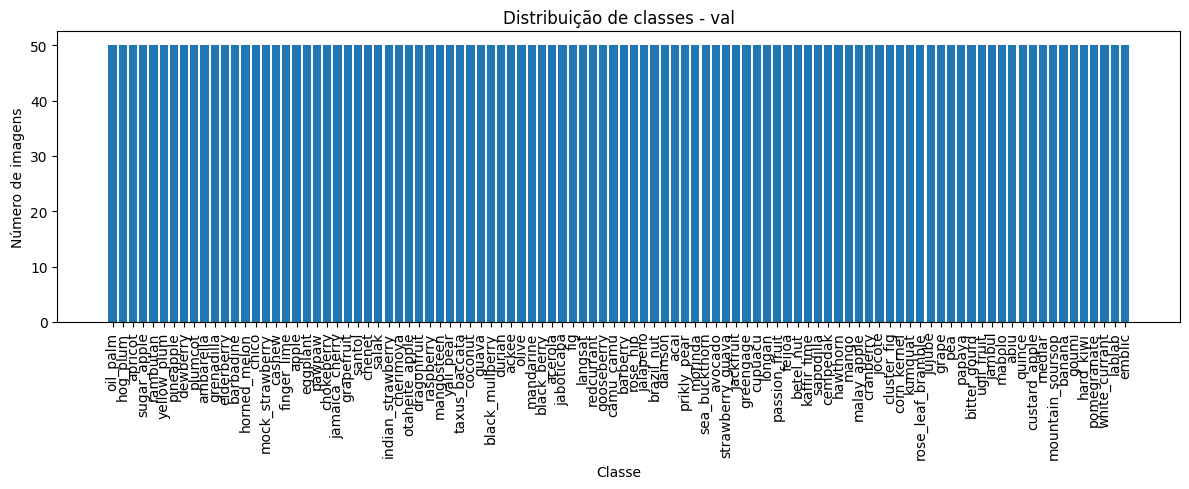

Classe com mais imagens: 50 | Classe com menos imagens: 50
Razão maior/menor: 1.00x
Classes relativamente balanceadas.


In [10]:
"""
Script de verificação de DISTRIBUIÇÃO DAS CLASSES - ATIV-04-ET-01
Fruit_dataset - Bootcamp Avanti
"""

import os
import pandas as pd
import matplotlib.pyplot as plt

base_path = r'C:\Users\ferre\Projects\LearnPython\BootcampAvanti\Bootcamp_Avanti_2026\Fruit_dataset'

# Carrega os CSVs (ajuste os nomes se necessário)
train_df = pd.read_csv(os.path.join(base_path, 'train.csv'))
val_df = pd.read_csv(os.path.join(base_path, 'val.csv'))
# test.csv não tem rótulo de verdade (category = -1 sempre), então não entra
# na análise de distribuição de classes

# Se você tiver o classname.txt com nome_da_classe <-> índice, carregue aqui
# para trocar o número da categoria pelo nome da fruta.
classname_path = os.path.join(base_path, 'classname.txt')
mapa_classes = {}
if os.path.exists(classname_path):
    with open(classname_path, 'r', encoding='utf-8') as f:
        linhas = f.readlines()
    # ajuste este parsing conforme o formato real do seu classname.txt
    # Ex esperado: "0 oil_palm" por linha, ou "oil_palm" por linha (índice = posição)
    for i, linha in enumerate(linhas):
        linha = linha.strip()
        if not linha:
            continue
        partes = linha.split(maxsplit=1)
        if len(partes) == 2 and partes[0].isdigit():
            mapa_classes[int(partes[0])] = partes[1]
        else:
            mapa_classes[i] = linha

def contar_classes(df, nome_conjunto):
    contagem = df['category'].value_counts().sort_index()
    print(f"\n===== Distribuição de classes: {nome_conjunto} =====")
    print(f"Número de classes distintas: {df['category'].nunique()}")
    print(contagem)

    # Aplica nomes de classe, se disponível
    if mapa_classes:
        labels = [mapa_classes.get(idx, str(idx)) for idx in contagem.index]
    else:
        labels = [str(idx) for idx in contagem.index]

    plt.figure(figsize=(12, 5))
    plt.bar(labels, contagem.values)
    plt.xticks(rotation=90)
    plt.title(f"Distribuição de classes - {nome_conjunto}")
    plt.xlabel("Classe")
    plt.ylabel("Número de imagens")
    plt.tight_layout()
    plt.savefig(f"distribuicao_classes_{nome_conjunto}.png")
    plt.show()

    # Sinaliza desequilíbrio: se a classe mais frequente tem mais que
    # o dobro de imagens da classe menos frequente, por exemplo
    maior = contagem.max()
    menor = contagem.min()
    razao = maior / menor if menor > 0 else float('inf')
    print(f"Classe com mais imagens: {maior} | Classe com menos imagens: {menor}")
    print(f"Razão maior/menor: {razao:.2f}x")
    if razao > 2:
        print("[ATENÇÃO] Possível desequilíbrio entre classes (razão > 2x).")
    else:
        print("Classes relativamente balanceadas.")

contar_classes(train_df, 'train')
contar_classes(val_df, 'val')